In [1]:
# ==========================================
# STEP 1: Install Required Libraries
# ==========================================

!pip install shap lime kagglehub -q

print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# For reproducibility
np.random.seed(42)
shap.initjs()   # initialise SHAP JavaScript visualisations

print("✅ Imports complete!")

✅ Imports complete!


In [4]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("fatemehmehrparvar/obesity-levels")

print("Path:", path)

# See available files
print(os.listdir(path))

100%|██████████| 57.6k/57.6k [00:00<00:00, 18.2MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/fatemehmehrparvar/obesity-levels/versions/1
['ObesityDataSet_raw_and_data_sinthetic.csv']


In [5]:
csv_file = os.path.join(path, "ObesityDataSet_raw_and_data_sinthetic.csv")

df = pd.read_csv(csv_file)

print(f"Dataset shape: {df.shape}")
print(df['NObeyesdad'].value_counts())

df.head()

Dataset shape: (2111, 17)
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


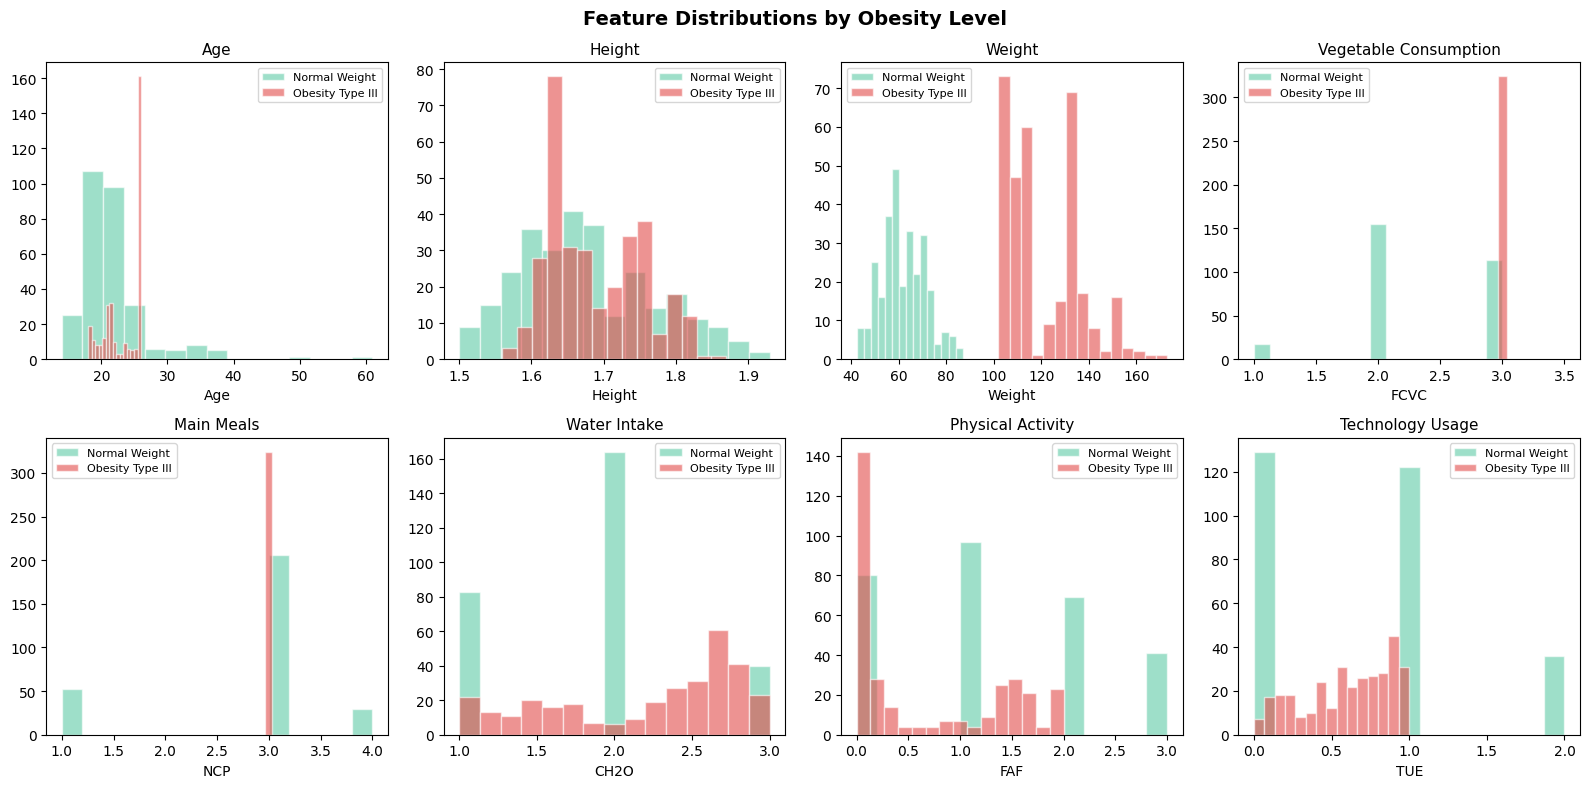

💡 Notice which features separate Normal Weight and Obesity Type III most clearly — SHAP will confirm this!


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions by Obesity Level', fontsize=14, fontweight='bold')

features_to_plot = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'CH2O',
    'FAF',
    'TUE'
]

labels = [
    'Age',
    'Height',
    'Weight',
    'Vegetable Consumption',
    'Main Meals',
    'Water Intake',
    'Physical Activity',
    'Technology Usage'
]

# Compare Normal Weight vs Obesity Type III
normal = df[df['NObeyesdad'] == 'Normal_Weight']
obese = df[df['NObeyesdad'] == 'Obesity_Type_III']

for ax, feat, lbl in zip(axes.flatten(), features_to_plot, labels):

    ax.hist(
        normal[feat],
        bins=15,
        alpha=0.6,
        color='#5DCAA5',
        label='Normal Weight',
        edgecolor='white'
    )

    ax.hist(
        obese[feat],
        bins=15,
        alpha=0.6,
        color='#E24B4A',
        label='Obesity Type III',
        edgecolor='white'
    )

    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Notice which features separate Normal Weight and Obesity Type III most clearly — SHAP will confirm this!")

In [7]:
# Features and Target

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

feature_names = X.columns.tolist()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

print(f"\n✅ Model Accuracy : {acc:.4f} ({acc*100:.1f}%)")

print("\nDetailed Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

Training samples : 1688
Testing  samples : 423

✅ Model Accuracy : 0.9574 (95.7%)

Detailed Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.84      0.98      0.90        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



Model and data already loaded.

SHAP values shape: (423, 16)
= (423 patients, 16 features)


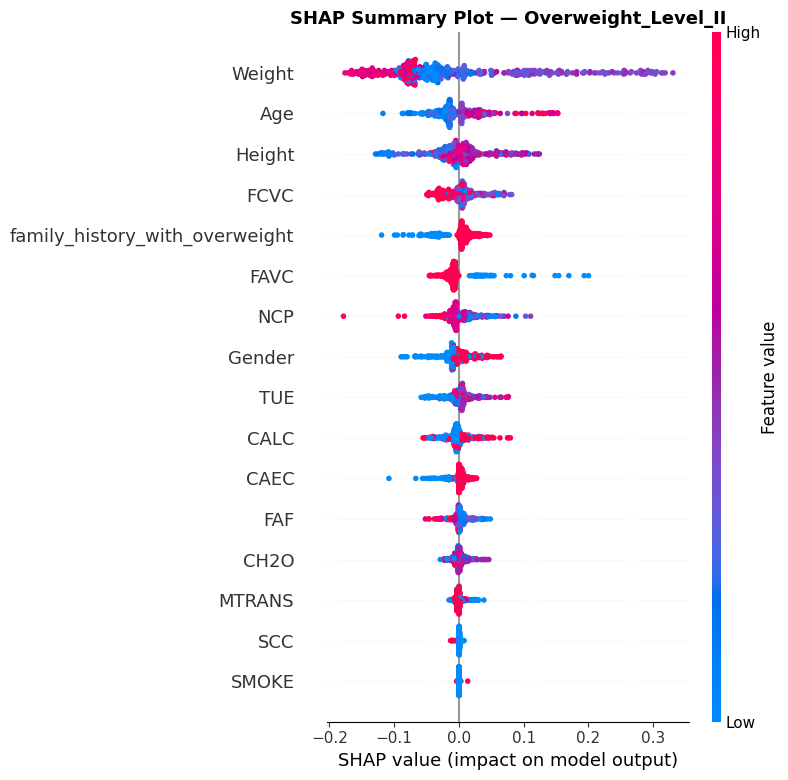

💡 X-axis = SHAP value
💡 Red = high feature value
💡 Blue = low feature value
💡 Features at the top have the strongest influence on obesity prediction


In [8]:
# =====================================================
# SHAP - Global Feature Importance (Obesity Dataset)
# =====================================================

if 'model' not in dir() or 'X_test' not in dir():
    print("Model not found. Run previous cells first.")
else:
    print("Model and data already loaded.")

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle multiclass output
if isinstance(shap_values, list):
    obesity_class = len(shap_values) - 1
    shap_class = shap_values[obesity_class]
else:
    obesity_class = len(target_encoder.classes_) - 1
    shap_class = shap_values[:, :, obesity_class]

print(f"\nSHAP values shape: {shap_class.shape}")
print(f"= ({len(X_test)} patients, {len(feature_names)} features)")

# SHAP Summary Plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_class,
    X_test,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)

plt.title(
    f'SHAP Summary Plot — {target_encoder.classes_[obesity_class]}',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('shap_summary_obesity.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 X-axis = SHAP value")
print("💡 Red = high feature value")
print("💡 Blue = low feature value")
print("💡 Features at the top have the strongest influence on obesity prediction")

Model and data already loaded.


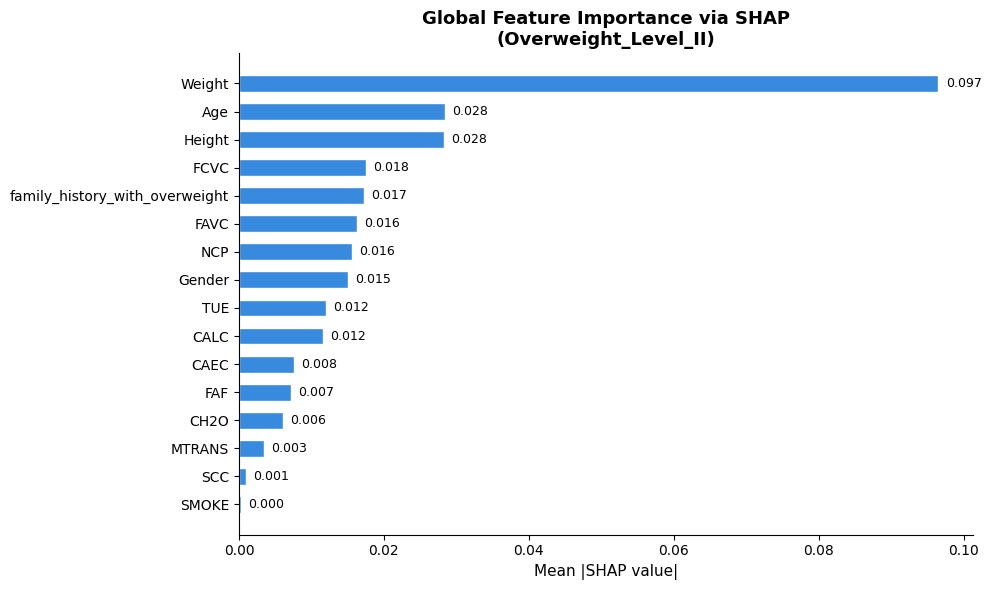


Top 5 most important features:
                       Feature  Mean |SHAP|
                        Weight     0.096534
                           Age     0.028389
                        Height     0.028338
                          FCVC     0.017539
family_history_with_overweight     0.017248


In [9]:
# =====================================================
# SHAP Feature Importance Bar Chart (Obesity Dataset)
# =====================================================

if 'model' not in dir():
    print("Run model training cell first.")
else:
    print("Model and data already loaded.")

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle multiclass output
if isinstance(shap_values, list):
    obesity_class = len(shap_values) - 1
    shap_class = shap_values[obesity_class]
else:
    obesity_class = len(target_encoder.classes_) - 1
    shap_class = shap_values[:, :, obesity_class]

# Mean absolute SHAP values
mean_shap = np.abs(shap_class).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    importance_df['Feature'],
    importance_df['Mean |SHAP|'],
    color='#378ADD',
    edgecolor='white',
    height=0.6
)

ax.set_xlabel('Mean |SHAP value|', fontsize=11)

ax.set_title(
    f'Global Feature Importance via SHAP\n({target_encoder.classes_[obesity_class]})',
    fontsize=13,
    fontweight='bold'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, importance_df['Mean |SHAP|']):
    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('shap_bar_obesity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")

print(
    importance_df.tail(5)[['Feature','Mean |SHAP|']]
    .sort_values('Mean |SHAP|', ascending=False)
    .to_string(index=False)
)

Person #0
True Class : Insufficient_Weight
Predicted  : Insufficient_Weight
Confidence : 0.910

Feature Values:
Age            : 19.084967
Gender         : 0.0
Height         : 1.768435
Weight         : 49.597765
CALC           : 2.0
FAVC           : 1.0
FCVC           : 3.0
NCP            : 3.725797
SCC            : 0.0
SMOKE          : 0.0
CH2O           : 1.191401
family_history_with_overweight: 0.0
FAF            : 2.0
TUE            : 1.0
CAEC           : 2.0
MTRANS         : 3.0


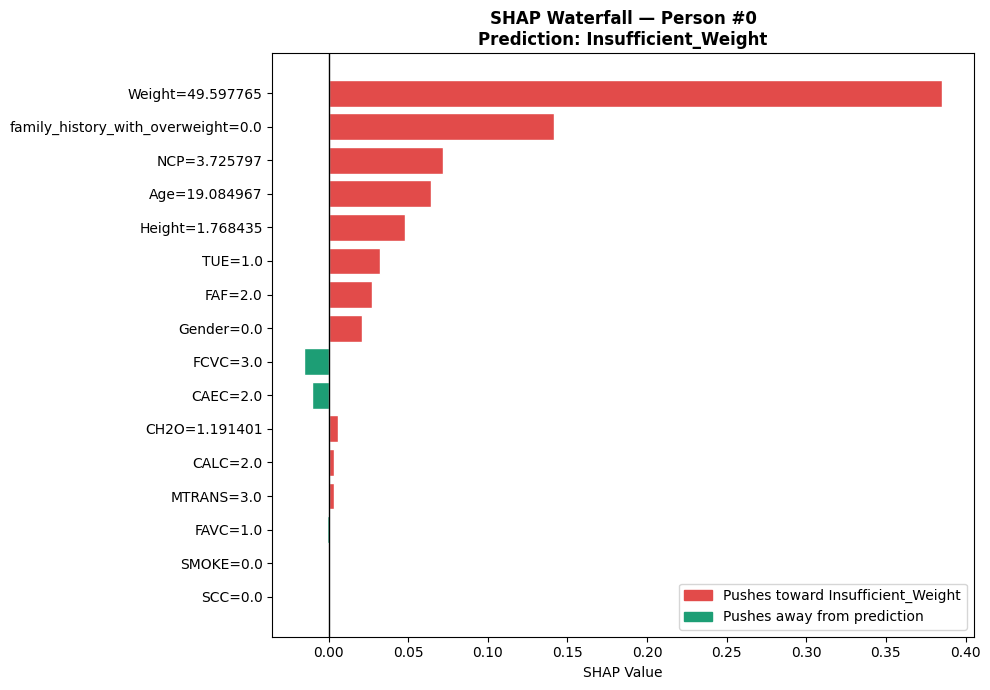

In [10]:
# =====================================================
# SHAP Local Explanation - Individual Person
# =====================================================

patient_idx = 0   # change me

patient = X_test[patient_idx]

pred_prob = model.predict_proba(patient.reshape(1,-1))[0]
pred_label = model.predict(patient.reshape(1,-1))[0]

true_class = target_encoder.inverse_transform([y_test[patient_idx]])[0]
pred_class = target_encoder.inverse_transform([pred_label])[0]

print(f"Person #{patient_idx}")
print(f"True Class : {true_class}")
print(f"Predicted  : {pred_class}")
print(f"Confidence : {np.max(pred_prob):.3f}")

print("\nFeature Values:")
for name, val in zip(feature_names, patient):
    print(f"{name:15s}: {val}")

# ------------------------------------------
# SHAP values for predicted class
# ------------------------------------------

if isinstance(shap_values, list):
    patient_shap = shap_values[pred_label][patient_idx]
else:
    patient_shap = shap_values[patient_idx, :, pred_label]

shap_df = pd.DataFrame({
    'Feature': [f"{n}={v}" for n,v in zip(feature_names, patient)],
    'SHAP': patient_shap
})

shap_df = shap_df.sort_values(
    by='SHAP',
    key=lambda x: np.abs(x),
    ascending=True
)

fig, ax = plt.subplots(figsize=(10,7))

colors = [
    '#E24B4A' if x > 0 else '#1D9E75'
    for x in shap_df['SHAP']
]

ax.barh(
    shap_df['Feature'],
    shap_df['SHAP'],
    color=colors,
    edgecolor='white'
)

ax.axvline(0,color='black',linewidth=1)

ax.set_title(
    f'SHAP Waterfall — Person #{patient_idx}\nPrediction: {pred_class}',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('SHAP Value')

red_patch = mpatches.Patch(
    color='#E24B4A',
    label=f'Pushes toward {pred_class}'
)

green_patch = mpatches.Patch(
    color='#1D9E75',
    label='Pushes away from prediction'
)

ax.legend(handles=[red_patch, green_patch])

plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# Interactive SHAP Force Plot (Obesity Dataset)
# =====================================================

import shap
from IPython.display import display, HTML

shap.initjs()

person_idx = 0

pred_label = model.predict(X_test[person_idx].reshape(1,-1))[0]
pred_class = target_encoder.inverse_transform([pred_label])[0]

print(f"Person #{person_idx}")
print(f"Predicted Class: {pred_class}")

# Recompute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Multiclass handling
if isinstance(shap_values, list):
    person_shap = shap_values[pred_label][person_idx]
    base_value = explainer.expected_value[pred_label]
else:
    person_shap = shap_values[person_idx, :, pred_label]
    base_value = explainer.expected_value[pred_label]

# Force Plot
force_plot = shap.force_plot(
    base_value,
    person_shap,
    X_test[person_idx],
    feature_names=feature_names
)

display(force_plot)

Person #0
Predicted Class: Insufficient_Weight


Plotting SHAP dependence for: Weight
Class: Overweight_Level_II


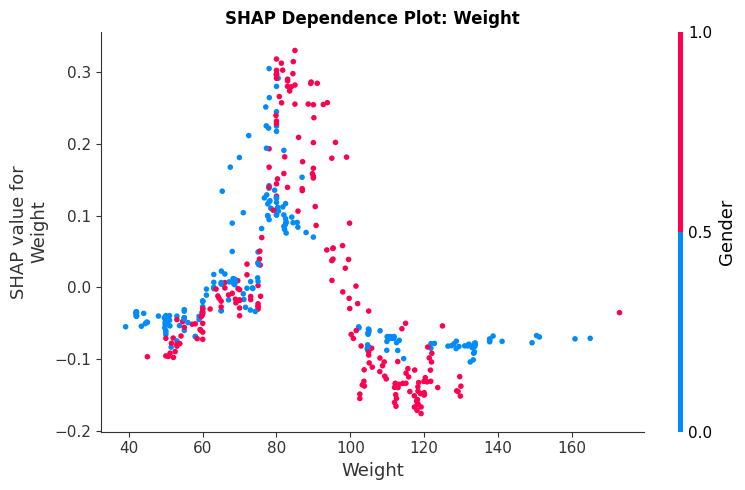

💡 X-axis = Feature Value
💡 Y-axis = SHAP Value
💡 Color = Interacting Feature
💡 Positive SHAP values increase the likelihood of the obesity class


In [14]:
# =====================================================
# SHAP Dependence Plot - Obesity Dataset
# =====================================================

import shap
import matplotlib.pyplot as plt

# -------------------------------------------------------
# STUDENT TASK:
# Try changing the feature below
# Weight, Height, Age, FAF, CH2O, FCVC, TUE
# -------------------------------------------------------

feature_to_plot = 'Weight'   # <-- change me

# Recompute SHAP values if needed
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Select Obesity_Type_III class
if isinstance(shap_values, list):
    obesity_class = len(shap_values) - 1
    shap_class = shap_values[obesity_class]
else:
    obesity_class = len(target_encoder.classes_) - 1
    shap_class = shap_values[:, :, obesity_class]

print(f"Plotting SHAP dependence for: {feature_to_plot}")
print(f"Class: {target_encoder.classes_[obesity_class]}")

fig, ax = plt.subplots(figsize=(8,5))

shap.dependence_plot(
    feature_to_plot,
    shap_class,
    X_test,
    feature_names=feature_names,
    ax=ax,
    show=False
)

ax.set_title(
    f'SHAP Dependence Plot: {feature_to_plot}',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    f'shap_dependence_{feature_to_plot}.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("💡 X-axis = Feature Value")
print("💡 Y-axis = SHAP Value")
print("💡 Color = Interacting Feature")
print("💡 Positive SHAP values increase the likelihood of the obesity class")

In [15]:
# =====================================================
# LIME Explainer Setup - Obesity Dataset
# =====================================================

import lime
import lime.lime_tabular

if 'model' not in dir():
    print("Run model training cell first.")
else:
    print("Model and data already loaded.")

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=list(target_encoder.classes_),
    mode='classification',
    random_state=42
)

print("✅ LIME explainer created!")

print(f"Training distribution shape: {X_train.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of classes: {len(target_encoder.classes_)}")

print("\nClasses:")
for i, cls in enumerate(target_encoder.classes_):
    print(f"{i}: {cls}")

print("\nThe explainer will sample perturbations from this training distribution.")

Model and data already loaded.
✅ LIME explainer created!
Training distribution shape: (1688, 16)
Number of features: 16
Number of classes: 7

Classes:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II

The explainer will sample perturbations from this training distribution.


In [17]:
# -------------------------------------------------------
# STUDENT TASK: Change person_idx and num_features
# -------------------------------------------------------

person_idx = 0
num_features = 8

lime_exp = lime_explainer.explain_instance(
    data_row=X_test[person_idx],
    predict_fn=model.predict_proba,
    num_features=num_features,
    num_samples=1000,
    top_labels=1
)

pred_probs = model.predict_proba(
    X_test[person_idx].reshape(1,-1)
)[0]

pred_class_idx = np.argmax(pred_probs)
pred_class = target_encoder.classes_[pred_class_idx]

print(f"Person #{person_idx} — LIME Explanation")
print(f"Predicted probability of {pred_class}: {pred_probs[pred_class_idx]:.3f}")
print()
print("Feature conditions and their weights:")

lime_label = lime_exp.available_labels()[0]

for feat, weight in lime_exp.as_list(label=lime_label):

    direction = (
        f"↑ increases {pred_class}"
        if weight > 0
        else f"↓ decreases {pred_class}"
    )

    print(
        f"  {feat:35s}: {weight:+.4f}  ({direction})"
    )

Person #0 — LIME Explanation
Predicted probability of Insufficient_Weight: 0.910

Feature conditions and their weights:
  Weight <= 65.14                    : +0.2880  (↑ increases Insufficient_Weight)
  NCP > 3.00                         : +0.0640  (↑ increases Insufficient_Weight)
  Age <= 19.92                       : +0.0415  (↑ increases Insufficient_Weight)
  SMOKE <= 0.00                      : +0.0397  (↑ increases Insufficient_Weight)
  CAEC <= 2.00                       : +0.0375  (↑ increases Insufficient_Weight)
  2.41 < FCVC <= 3.00                : +0.0319  (↑ increases Insufficient_Weight)
  CALC <= 2.00                       : -0.0225  (↓ decreases Insufficient_Weight)
  MTRANS <= 3.00                     : -0.0186  (↓ decreases Insufficient_Weight)


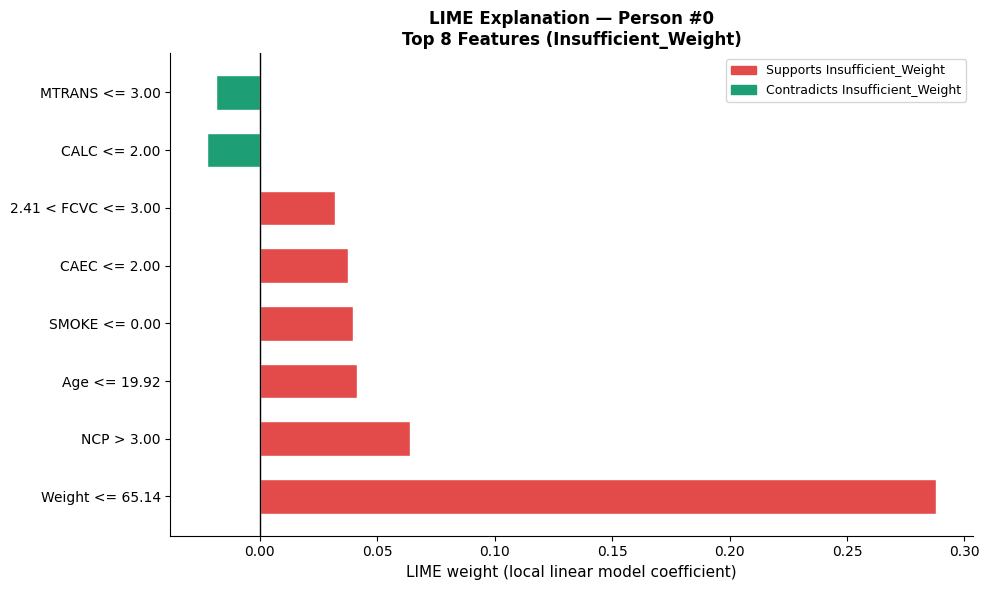

In [18]:
# =====================================================
# LIME Bar Chart - Obesity Dataset
# =====================================================

# Get the class that LIME explained
lime_label = lime_exp.available_labels()[0]

lime_list = lime_exp.as_list(label=lime_label)

features_lime = [x[0] for x in lime_list]
weights_lime = [x[1] for x in lime_list]

colors_lime = [
    '#E24B4A' if w > 0 else '#1D9E75'
    for w in weights_lime
]

pred_class = target_encoder.classes_[lime_label]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(features_lime))

ax.barh(
    y_pos,
    weights_lime,
    color=colors_lime,
    edgecolor='white',
    height=0.6
)

ax.set_yticks(y_pos)
ax.set_yticklabels(features_lime, fontsize=10)

ax.axvline(0, color='black', linewidth=1)

ax.set_xlabel(
    'LIME weight (local linear model coefficient)',
    fontsize=11
)

ax.set_title(
    f'LIME Explanation — Person #{patient_idx}\n'
    f'Top {num_features} Features ({pred_class})',
    fontsize=12,
    fontweight='bold'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

red_patch = mpatches.Patch(
    color='#E24B4A',
    label=f'Supports {pred_class}'
)

green_patch = mpatches.Patch(
    color='#1D9E75',
    label=f'Contradicts {pred_class}'
)

ax.legend(
    handles=[red_patch, green_patch],
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    f'lime_person_{patient_idx}.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [19]:
# =====================================================
# Interactive LIME Visualization
# =====================================================

patient_idx = 0
num_features = 8

lime_exp = lime_explainer.explain_instance(
    data_row=X_test[patient_idx],
    predict_fn=model.predict_proba,
    num_features=num_features,
    num_samples=1000,
    top_labels=1
)

# Interactive HTML visualization
lime_exp.show_in_notebook(
    show_table=True,
    show_all=False
)

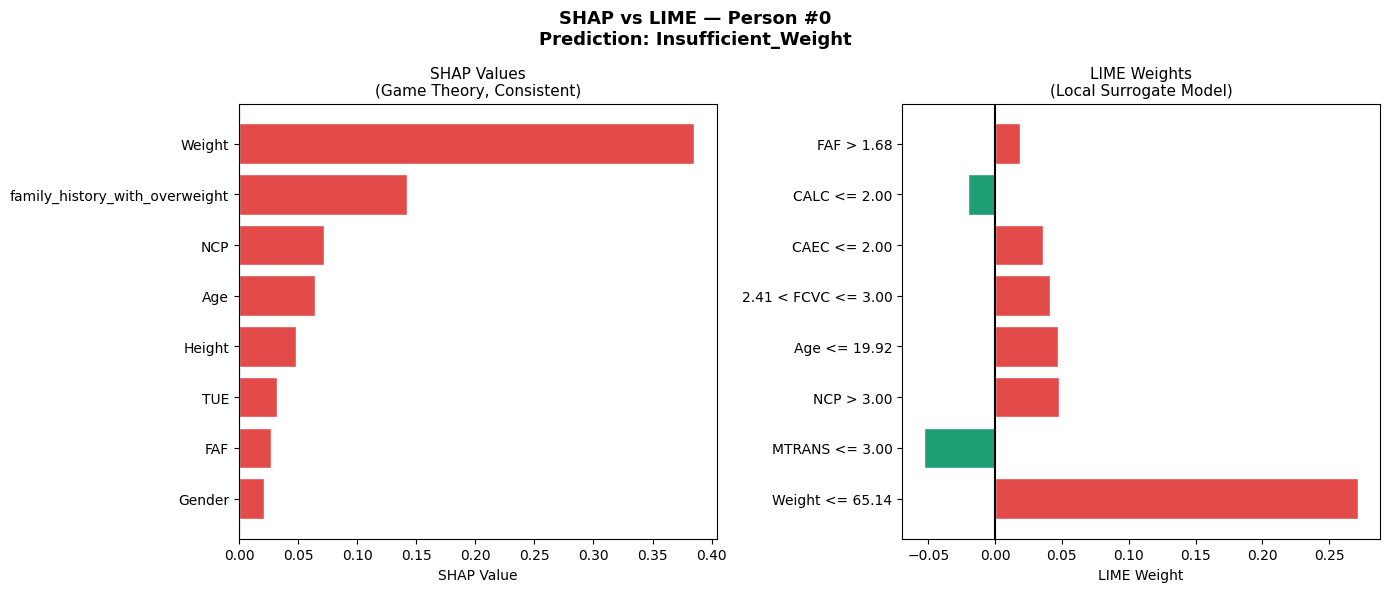


Reflection Questions:
1. Do SHAP and LIME agree on the most important feature?
2. Does LIME explain using conditions or raw values?
3. Which explanation is easier to understand?
4. Which features drive the obesity prediction most strongly?


In [20]:
# =====================================================
# SHAP vs LIME Comparison - Obesity Dataset
# =====================================================

patient_idx = 0   # <-- change me

# Prediction
pred_probs = model.predict_proba(
    X_test[patient_idx].reshape(1,-1)
)[0]

pred_class_idx = np.argmax(pred_probs)
pred_class = target_encoder.classes_[pred_class_idx]

# ------------------------------------------
# SHAP values
# ------------------------------------------

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_patient = shap_values[pred_class_idx][patient_idx]
else:
    shap_patient = shap_values[patient_idx, :, pred_class_idx]

shap_df_compare = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': shap_patient
})

shap_df_compare['abs_SHAP'] = np.abs(shap_df_compare['SHAP'])

shap_df_compare = (
    shap_df_compare
    .sort_values('abs_SHAP', ascending=False)
    .head(8)
)

# ------------------------------------------
# LIME values
# ------------------------------------------

lime_exp2 = lime_explainer.explain_instance(
    X_test[patient_idx],
    model.predict_proba,
    num_features=8,
    num_samples=1000,
    top_labels=1
)

lime_label = lime_exp2.available_labels()[0]

# ------------------------------------------
# Plot
# ------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

fig.suptitle(
    f'SHAP vs LIME — Person #{patient_idx}\nPrediction: {pred_class}',
    fontsize=13,
    fontweight='bold'
)

# ========= SHAP =========

shap_sorted = shap_df_compare.sort_values('SHAP')

colors_s = [
    '#E24B4A' if v > 0 else '#1D9E75'
    for v in shap_sorted['SHAP']
]

ax1.barh(
    shap_sorted['Feature'],
    shap_sorted['SHAP'],
    color=colors_s,
    edgecolor='white'
)

ax1.axvline(0, color='black')

ax1.set_title(
    'SHAP Values\n(Game Theory, Consistent)',
    fontsize=11
)

ax1.set_xlabel('SHAP Value')

# ========= LIME =========

lime_items = lime_exp2.as_list(label=lime_label)

lime_feats = [x[0] for x in lime_items]
lime_vals = [x[1] for x in lime_items]

colors_l = [
    '#E24B4A' if v > 0 else '#1D9E75'
    for v in lime_vals
]

ax2.barh(
    lime_feats,
    lime_vals,
    color=colors_l,
    edgecolor='white'
)

ax2.axvline(0, color='black')

ax2.set_title(
    'LIME Weights\n(Local Surrogate Model)',
    fontsize=11
)

ax2.set_xlabel('LIME Weight')

plt.tight_layout()
plt.show()

print("\nReflection Questions:")
print("1. Do SHAP and LIME agree on the most important feature?")
print("2. Does LIME explain using conditions or raw values?")
print("3. Which explanation is easier to understand?")
print("4. Which features drive the obesity prediction most strongly?")

In [21]:
# =====================================================
# Find Most Uncertain Person - Obesity Dataset
# =====================================================

# Predict probabilities for all test samples
probs = model.predict_proba(X_test)

# Highest probability for each prediction
max_probs = np.max(probs, axis=1)

# Most uncertain prediction
hardest_idx = np.argmin(max_probs)

pred_class_idx = np.argmax(probs[hardest_idx])
pred_class = target_encoder.classes_[pred_class_idx]

true_class = target_encoder.classes_[y_test[hardest_idx]]

print(f"Most uncertain person index: {hardest_idx}")
print(f"Prediction confidence: {max_probs[hardest_idx]:.4f}")
print(f"Predicted class: {pred_class}")
print(f"True class: {true_class}")

print("\n" + "="*50)
print("Feature Values")
print("="*50)

for feat, val in zip(feature_names, X_test[hardest_idx]):
    print(f"{feat:15s}: {val}")

# -------------------------------------------------------
# STUDENT TASK:
# Explain this person using SHAP and LIME
# -------------------------------------------------------

# SHAP Explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    person_shap = shap_values[pred_class_idx][hardest_idx]
else:
    person_shap = shap_values[hardest_idx, :, pred_class_idx]

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': person_shap
})

shap_df['Abs_SHAP'] = np.abs(shap_df['SHAP'])

print("\nTop SHAP Features:")
print(
    shap_df
    .sort_values('Abs_SHAP', ascending=False)
    .head(5)[['Feature','SHAP']]
    .to_string(index=False)
)

# LIME Explanation

lime_exp = lime_explainer.explain_instance(
    X_test[hardest_idx],
    model.predict_proba,
    num_features=5,
    num_samples=1000,
    top_labels=1
)

lime_label = lime_exp.available_labels()[0]

print("\nTop LIME Features:")

for feat, weight in lime_exp.as_list(label=lime_label):
    print(f"{feat:35s}: {weight:+.4f}")

print("\nReflection Questions:")
print("1. Why was this person difficult to classify?")
print("2. Do SHAP and LIME highlight similar features?")
print("3. Which features caused uncertainty?")
print("4. How could model confidence be improved?")

Most uncertain person index: 34
Prediction confidence: 0.2700
Predicted class: Obesity_Type_I
True class: Obesity_Type_III

Feature Values
Age            : 18.0
Gender         : 1.0
Height         : 1.87
Weight         : 173.0
CALC           : 2.0
FAVC           : 1.0
FCVC           : 3.0
NCP            : 3.0
SCC            : 0.0
SMOKE          : 0.0
CH2O           : 2.0
family_history_with_overweight: 1.0
FAF            : 2.0
TUE            : 1.0
CAEC           : 1.0
MTRANS         : 3.0

Top SHAP Features:
Feature      SHAP
 Gender  0.075198
 Weight  0.070717
   FCVC -0.060844
    Age  0.030291
   CAEC -0.012897

Top LIME Features:
Weight > 107.05                    : +0.0741
Age <= 19.92                       : +0.0443
2.41 < FCVC <= 3.00                : -0.0420
CALC <= 2.00                       : -0.0330
Height > 1.77                      : -0.0279

Reflection Questions:
1. Why was this person difficult to classify?
2. Do SHAP and LIME highlight similar features?
3. Which feature